# BrainScanAI — Pipeline complet avec RadImageNet (ResNet50 médical)

Ce notebook utilise **RadImageNet**, un ResNet50 pré-entraîné sur **1.35 million d'images médicales** (IRM, scanner CT, échographie). C'est le choix le plus pertinent pour notre tâche car les features apprises sont directement adaptées à l'imagerie médicale, contrairement à ImageNet.

**Pipeline** :
1. Téléchargement des poids RadImageNet via HuggingFace Hub
2. Extraction de features (embeddings 2048 dim) sur tout le dataset
3. Clustering exploratoire + pseudo-labels (K-Means, DBSCAN, ARI)
4. Comparaison 3 modèles : faible seul / semi-supervisé / supervisé seul
5. Prédiction sur le pool non étiqueté avec score de confiance

In [1]:
import sys
get_ipython().system(f'{sys.executable} -m pip install torch torchvision huggingface_hub scikit-image scikit-learn numpy pandas matplotlib pillow scipy --quiet')
print("Installation terminée.")
import sys
!{sys.executable} -m pip install torch torchvision huggingface_hub scikit-image scikit-learn numpy pandas matplotlib pillow scipy opencv-python --quiet
print("Installation terminée.")

Installation terminée.
Installation terminée.


In [2]:
import time, copy, hashlib, warnings, zipfile
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
from skimage.feature import hog
from huggingface_hub import hf_hub_download
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (adjusted_rand_score, silhouette_score,
                             accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
from sklearn.model_selection import train_test_split

import matplotlib

torch.manual_seed(42)
np.random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
ZIP_PATH  = Path("mri_dataset_brain_cancer_oc.zip")
DATA_ROOT = Path("mri_dataset_brain_cancer_oc")

if not DATA_ROOT.exists():
    print("Extraction du zip...")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(".")
    print("OK.")

records = []
for split_dir, label in [
    (DATA_ROOT / "avec_labels" / "normal", "normal"),
    (DATA_ROOT / "avec_labels" / "cancer", "cancer"),
    (DATA_ROOT / "sans_label", None),
]:
    pool = "avec_labels" if label is not None else "sans_label"
    for fp in sorted(split_dir.glob("*.jpg")):
        records.append({"filepath": str(fp), "pool": pool, "label": label})

df = pd.DataFrame(records)

def md5_of(fp):
    with open(fp, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

df["md5"] = df["filepath"].apply(md5_of)
dup = df["md5"].value_counts()
dup = dup[dup > 1].index
cross = [h for h, g in df[df["md5"].isin(dup)].groupby("md5") if g["pool"].nunique() > 1]
df["exclude_recommended"] = (df["pool"] == "sans_label") & (df["md5"].isin(cross))

df_strong = df[df["pool"] == "avec_labels"].reset_index(drop=True)
df_weak   = df[(df["pool"] == "sans_label") & (~df["exclude_recommended"])].reset_index(drop=True)

print(f"avec_labels : {len(df_strong)} — {df_strong['label'].value_counts().to_dict()}")
print(f"sans_label  : {len(df_weak)} (après exclusion de {df['exclude_recommended'].sum()} doublons)")
# SPLIT TRAIN/TEST EN PREMIER — avant tout clustering et mapping
from sklearn.model_selection import train_test_split

train_strong, test_strong = train_test_split(
    df_strong, test_size=0.30, random_state=42,
    stratify=df_strong["label"]
)
print(f"train_strong : {len(train_strong)} {train_strong['label'].value_counts().to_dict()}")
print(f"test_strong  : {len(test_strong)} {test_strong['label'].value_counts().to_dict()} (jamais vu en entraînement)")

# Masque pour les 70 images de train — utilisé pour le clustering et le mapping
train_filepaths = set(train_strong["filepath"].tolist())

avec_labels : 100 — {'normal': 50, 'cancer': 50}
sans_label  : 1374 (après exclusion de 32 doublons)
train_strong : 70 {'normal': 35, 'cancer': 35}
test_strong  : 30 {'cancer': 15, 'normal': 15} (jamais vu en entraînement)


In [4]:
import torch
import torchvision.models as models
from huggingface_hub import hf_hub_download

print("Téléchargement des poids RadImageNet ResNet50 depuis HuggingFace...")
model_path = hf_hub_download(
    repo_id="Lab-Rasool/RadImageNet",
    filename="ResNet50.pt"
)
print(f"Poids disponibles -> {model_path}")

# 1. Créer l'architecture ResNet50
rad_full = models.resnet50(weights=None)

# 2. Charger les poids
state_dict = torch.load(model_path, map_location=DEVICE)

# 3. Retirer le préfixe "backbone." s'il existe
new_state = {k.replace("backbone.", ""): v for k, v in state_dict.items()}

# 4. Charger les poids dans le modèle
rad_full.load_state_dict(new_state, strict=False)

# 5. Envoyer le modèle sur le bon périphérique
rad_full.to(DEVICE)

# 6. Mode évaluation
rad_full.eval()

# Informations
n = sum(p.numel() for p in rad_full.parameters())
print(f"Modèle chargé : {n:,} paramètres")
print(f"Dernière couche : {rad_full.fc}")

Téléchargement des poids RadImageNet ResNet50 depuis HuggingFace...


Poids disponibles -> C:\Users\adda-\.cache\huggingface\hub\models--Lab-Rasool--RadImageNet\snapshots\14460ee4c1276f6925611a63aa9a54a05d39eae0\ResNet50.pt
Modèle chargé : 25,557,032 paramètres
Dernière couche : Linear(in_features=2048, out_features=1000, bias=True)


In [5]:
# Encodeur = RadImageNet sans la dernière couche FC -> embeddings 2048 dim
rad_encoder = nn.Sequential(*list(rad_full.children())[:-1]).to(DEVICE)
rad_encoder.eval()
for param in rad_encoder.parameters():
    param.requires_grad = False

print("Encodeur RadImageNet prêt (tous paramètres gelés).")
print("Dimension des embeddings : 2048")

Encodeur RadImageNet prêt (tous paramètres gelés).
Dimension des embeddings : 2048


In [6]:
TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class ImgDatasetRad(Dataset):
    def __init__(self, filepaths):
        self.fps = list(filepaths)
    def __len__(self): return len(self.fps)
    def __getitem__(self, i):
        with Image.open(self.fps[i]) as im:
            return TRANSFORM(im.convert("L"))

class ImgDatasetGray(Dataset):
    def __init__(self, filepaths, size=64):
        self.fps = list(filepaths); self.size = size
    def __len__(self): return len(self.fps)
    def __getitem__(self, i):
        with Image.open(self.fps[i]) as im:
            arr = np.array(im.convert("L").resize((self.size, self.size)), dtype=np.float32) / 255.0
        return torch.from_numpy(arr)[None]

def load_gray_np(fp, size=64):
    with Image.open(fp) as im:
        return np.array(im.convert("L").resize((size, size)), dtype=np.float32) / 255.0

print("Datasets définis.")

Datasets définis.


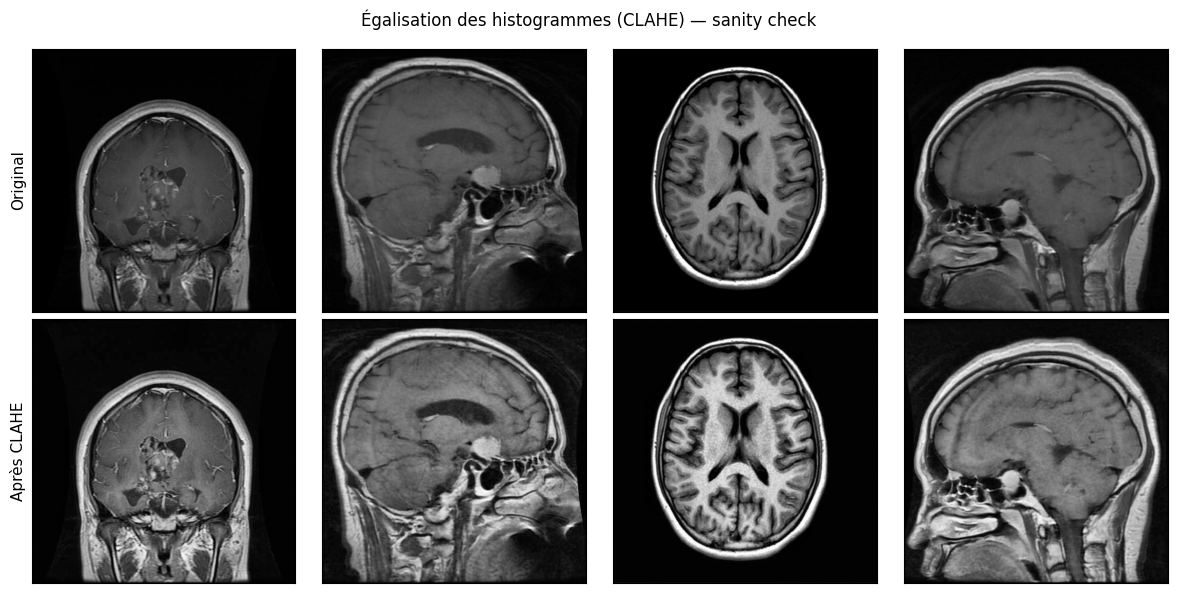

CLAHE défini et intégré aux deux datasets.


In [7]:
import cv2

def apply_clahe(fp, size=224):
    """Charge une image, applique CLAHE puis retourne un PIL Image."""
    with Image.open(fp) as im:
        arr = np.array(im.convert("L"), dtype=np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    arr_eq = clahe.apply(arr)
    return Image.fromarray(arr_eq)

class ImgDatasetRad(Dataset):
    
    def __init__(self, filepaths):
        self.fps = list(filepaths)
    def __len__(self): return len(self.fps)
    def __getitem__(self, i):
        img_eq = apply_clahe(self.fps[i])   
        return TRANSFORM(img_eq)            


class ClfDatasetEq(Dataset):
   
    def __init__(self, fps, labels, size=64):
        self.fps = list(fps)
        self.labels = [LABEL2IDX[l] for l in labels]
        self.size = size
    def __len__(self): return len(self.fps)
    def __getitem__(self, i):
        img_eq = apply_clahe(self.fps[i])
        arr = np.array(img_eq.resize((self.size, self.size)), dtype=np.float32) / 255.0
        return torch.from_numpy(arr)[None], self.labels[i]


fig, axes = plt.subplots(2, 4, figsize=(12, 6))
sample_fps = df_strong["filepath"].sample(4, random_state=1).tolist()
for j, fp in enumerate(sample_fps):
    with Image.open(fp) as im:
        arr_orig = np.array(im.convert("L"))
    arr_eq = np.array(apply_clahe(fp))
    axes[0, j].imshow(arr_orig, cmap="gray"); axes[0, j].set_xticks([]); axes[0, j].set_yticks([])
    axes[1, j].imshow(arr_eq,   cmap="gray"); axes[1, j].set_xticks([]); axes[1, j].set_yticks([])
axes[0, 0].set_ylabel("Original", fontsize=11)
axes[1, 0].set_ylabel("Après CLAHE", fontsize=11)
fig.suptitle("Égalisation des histogrammes (CLAHE) — sanity check")
plt.tight_layout()
plt.show()
print("CLAHE défini et intégré aux deux datasets.")


In [8]:
df_all = pd.concat([df_strong, df_weak], ignore_index=True)
is_strong = (df_all["pool"] == "avec_labels").values
y_true_strong = df_all.loc[is_strong, "label"].values

print(f"Extraction embeddings RadImageNet sur {len(df_all)} images...")
t0 = time.time()

embeds = []
loader = DataLoader(ImgDatasetRad(df_all["filepath"]), batch_size=32, shuffle=False)
with torch.no_grad():
    for i, batch in enumerate(loader):
        feat = rad_encoder(batch.to(DEVICE)).squeeze(-1).squeeze(-1)
        embeds.append(feat.cpu().numpy())
        if (i+1) % 10 == 0:
            print(f"  {min((i+1)*32, len(df_all))}/{len(df_all)} images...")

embeds = np.concatenate(embeds, axis=0)
print(f"Embeddings RadImageNet : {embeds.shape} en {time.time()-t0:.1f}s")
# Masque pour les 70 images de TRAIN uniquement (pas les 100)
is_train      = np.array([fp in train_filepaths for fp in df_all["filepath"]])
y_true_train  = df_all.loc[is_train, "label"].values
print(f"Images de train dans df_all : {is_train.sum()} (doit être 70)")

Extraction embeddings RadImageNet sur 1474 images...
  320/1474 images...
  640/1474 images...
  960/1474 images...
  1280/1474 images...
Embeddings RadImageNet : (1474, 2048) en 123.1s
Images de train dans df_all : 70 (doit être 70)


In [9]:
print("Extraction features HOG...")
t0 = time.time()
hog_feats = []
for fp in df_all["filepath"]:
    arr = (load_gray_np(fp) * 255).astype(np.uint8)
    hog_feats.append(hog(arr, orientations=8, pixels_per_cell=(8,8),
                         cells_per_block=(2,2), feature_vector=True))
hog_feats = np.stack(hog_feats)
print(f"HOG : {hog_feats.shape} en {time.time()-t0:.1f}s")

np.save("embeddings_radimagenet.npy", embeds)
np.save("features_hog.npy", hog_feats)
df_all.to_csv("manifest_full_ordered.csv", index=False)
print("Sauvegardé.")

Extraction features HOG...
HOG : (1474, 1568) en 11.0s
Sauvegardé.


In [10]:
X_rad = StandardScaler().fit_transform(embeds)
X_hog = StandardScaler().fit_transform(hog_feats)

pca_rad  = PCA(n_components=2, random_state=42)
pca2_rad = pca_rad.fit_transform(X_rad)
pca2_hog = PCA(n_components=2, random_state=42).fit_transform(X_hog)
print(f"PCA RadImageNet variance expliquée : {pca_rad.explained_variance_ratio_.sum():.1%}")

print("Calcul t-SNE...")
tsne2_rad = TSNE(n_components=2, random_state=42, perplexity=30, init="pca").fit_transform(X_rad)
print("t-SNE terminé.")

PCA RadImageNet variance expliquée : 75.9%
Calcul t-SNE...
t-SNE terminé.


In [11]:
def run_kmeans(Xf, name):
    km  = KMeans(n_clusters=2, random_state=42, n_init=10).fit(Xf)
    ari = adjusted_rand_score(y_true_train, km.labels_[is_train])
    sil = silhouette_score(Xf, km.labels_)
    print(f"[{name}] K-Means ARI={ari:.3f}  silhouette={sil:.3f}  {np.bincount(km.labels_)}")
    return km.labels_, ari

def sweep_dbscan(Xf, name):
    nn_ = NearestNeighbors(n_neighbors=10).fit(Xf)
    d, _ = nn_.kneighbors(Xf)
    base = np.percentile(np.sort(d[:,-1]), 90)
    best = None
    for m in [0.75, 1.0, 1.25]:
        db = DBSCAN(eps=base*m, min_samples=10).fit(Xf)
        nc = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
        ari = adjusted_rand_score(y_true_train, db.labels_[is_train]) if nc >= 2 else None
        print(f"[{name}] DBSCAN x{m} -> {nc} clusters, {(db.labels_==-1).sum()} bruit, ARI={ari}")
        if best is None and nc >= 2: best = db.labels_
    return best

print("=== RadImageNet ===")
km_rad, ari_rad = run_kmeans(X_rad, "RadImageNet")
db_rad = sweep_dbscan(X_rad, "RadImageNet")

print("\n=== HOG ===")
km_hog, ari_hog = run_kmeans(X_hog, "HOG")
db_hog = sweep_dbscan(X_hog, "HOG")

=== RadImageNet ===
[RadImageNet] K-Means ARI=-0.001  silhouette=0.362  [554 920]
[RadImageNet] DBSCAN x0.75 -> 5 clusters, 654 bruit, ARI=0.019130686198920586
[RadImageNet] DBSCAN x1.0 -> 1 clusters, 83 bruit, ARI=None
[RadImageNet] DBSCAN x1.25 -> 1 clusters, 18 bruit, ARI=None

=== HOG ===
[HOG] K-Means ARI=0.198  silhouette=0.083  [696 778]
[HOG] DBSCAN x0.75 -> 3 clusters, 999 bruit, ARI=0.03234637273971616
[HOG] DBSCAN x1.0 -> 1 clusters, 58 bruit, ARI=None
[HOG] DBSCAN x1.25 -> 1 clusters, 5 bruit, ARI=None


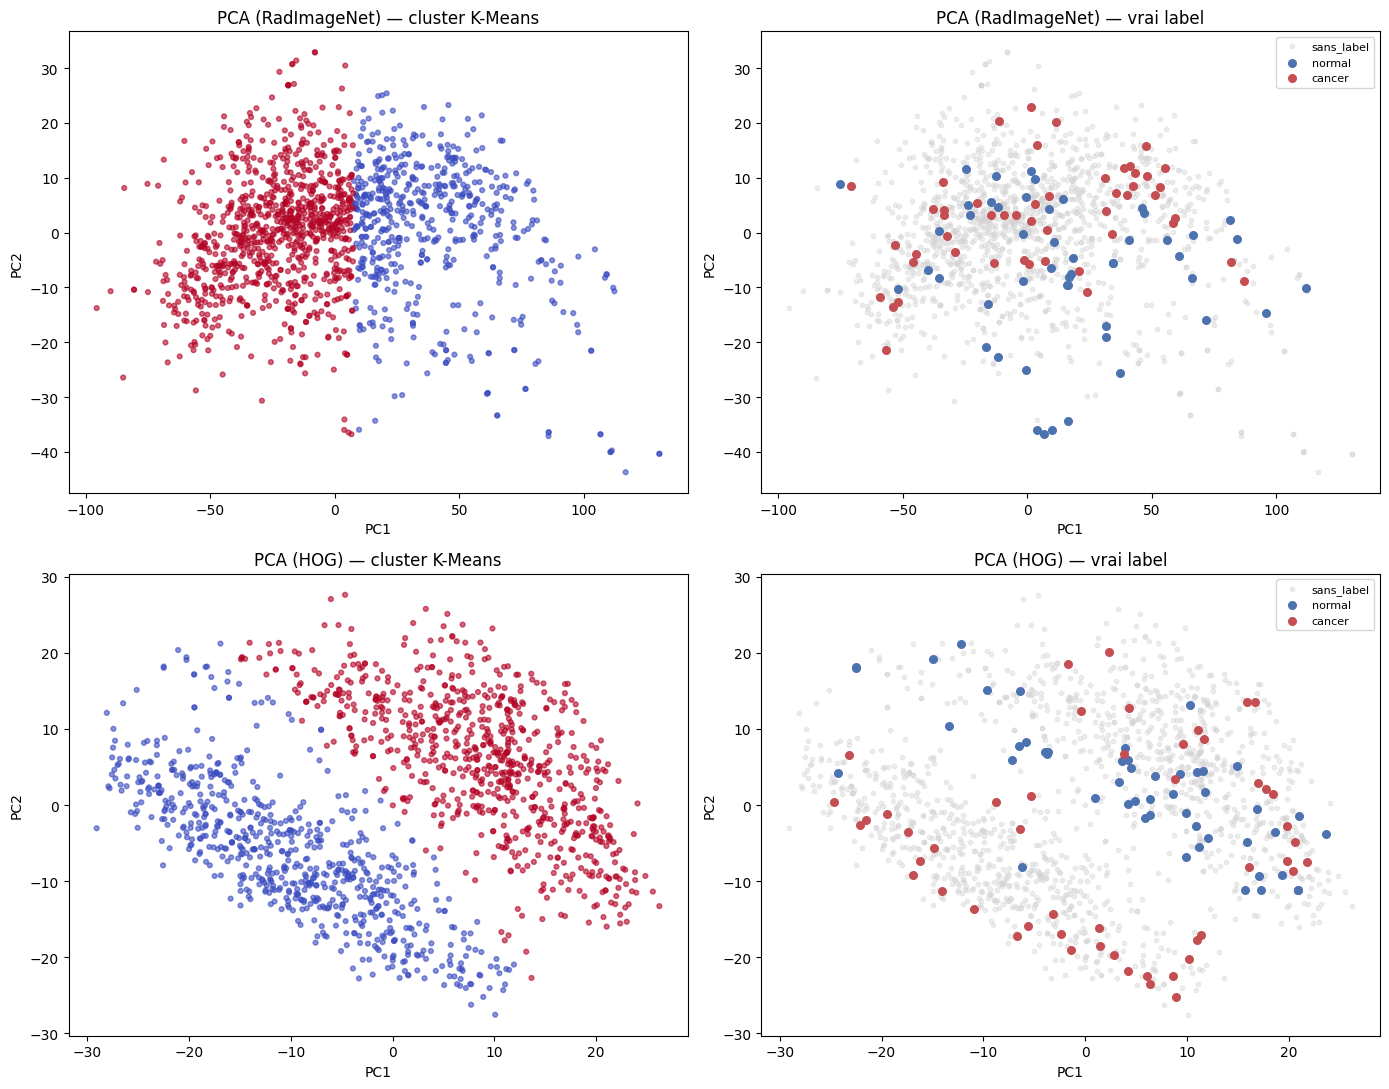

In [12]:
import matplotlib
matplotlib.use("inline")
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for row, (proj, km, feat) in enumerate([(pca2_rad, km_rad, "RadImageNet"),
                                         (pca2_hog, km_hog, "HOG")]):
    axes[row,0].scatter(proj[:,0], proj[:,1], c=km, cmap="coolwarm", s=12, alpha=0.6)
    axes[row,0].set_title(f"PCA ({feat}) — cluster K-Means")
    axes[row,0].set_xlabel("PC1"); axes[row,0].set_ylabel("PC2")

    ax = axes[row,1]
    ax.scatter(proj[~is_strong,0], proj[~is_strong,1], c="lightgrey", s=10, alpha=0.4, label="sans_label")
    ax.scatter(proj[is_strong & (df_all["label"]=="normal"),0],
               proj[is_strong & (df_all["label"]=="normal"),1], c="#4C72B0", s=30, label="normal")
    ax.scatter(proj[is_strong & (df_all["label"]=="cancer"),0],
               proj[is_strong & (df_all["label"]=="cancer"),1], c="#C44E52", s=30, label="cancer")
    ax.set_title(f"PCA ({feat}) — vrai label")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(fontsize=8)

plt.tight_layout(); plt.savefig("pca_radimagenet.png", dpi=130, bbox_inches="tight"); plt.show()

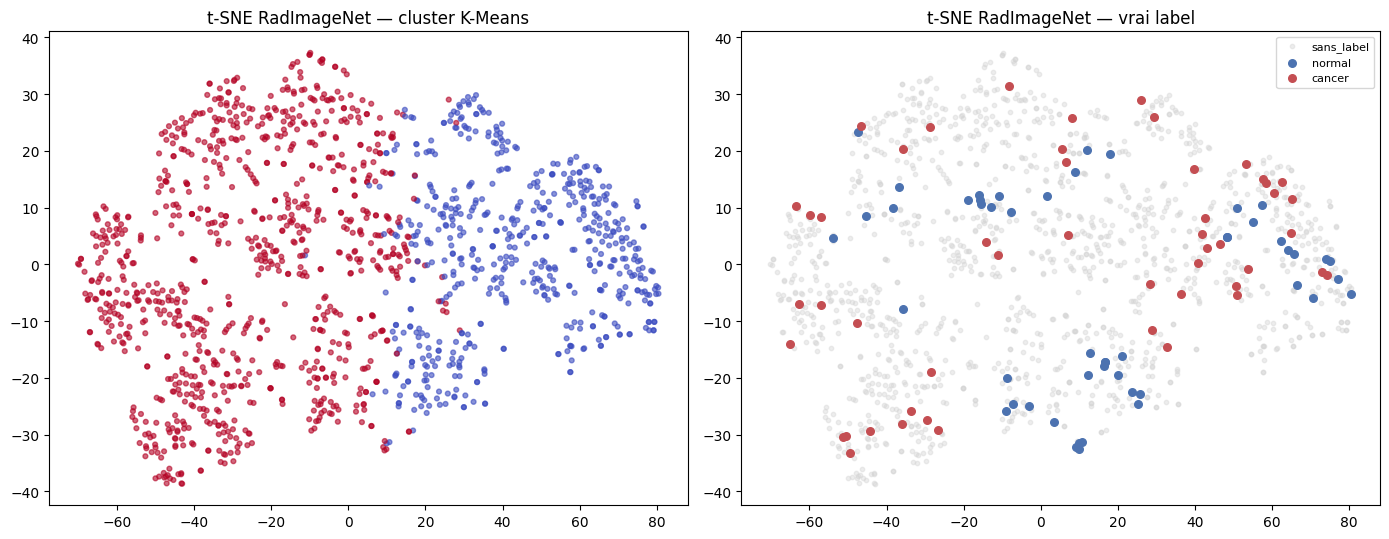

In [13]:
# t-SNE RadImageNet
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].scatter(tsne2_rad[:,0], tsne2_rad[:,1], c=km_rad, cmap="coolwarm", s=12, alpha=0.6)
axes[0].set_title("t-SNE RadImageNet — cluster K-Means")

ax = axes[1]
ax.scatter(tsne2_rad[~is_strong,0], tsne2_rad[~is_strong,1], c="lightgrey", s=10, alpha=0.4, label="sans_label")
ax.scatter(tsne2_rad[is_strong&(df_all["label"]=="normal"),0], tsne2_rad[is_strong&(df_all["label"]=="normal"),1], c="#4C72B0", s=30, label="normal")
ax.scatter(tsne2_rad[is_strong&(df_all["label"]=="cancer"),0], tsne2_rad[is_strong&(df_all["label"]=="cancer"),1], c="#C44E52", s=30, label="cancer")
ax.set_title("t-SNE RadImageNet — vrai label"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("tsne_radimagenet.png", dpi=130, bbox_inches="tight"); plt.show()

In [14]:
best_labels = km_rad if ari_rad >= ari_hog else km_hog
best_name   = "RadImageNet + K-Means" if ari_rad >= ari_hog else "HOG + K-Means"
best_ari    = max(ari_rad, ari_hog)
print(f"Meilleure combinaison : {best_name} (ARI={best_ari:.3f})")

mapping = {}
for cl in [0,1]:
    mask = is_train & (best_labels == cl)
    vals, counts = np.unique(df_all.loc[mask, "label"], return_counts=True)
    mapping[cl] = vals[np.argmax(counts)]
    print(f"  Cluster {cl} -> '{mapping[cl]}' {dict(zip(vals,counts))}")

df_all["pseudo_label"] = [mapping[c] for c in best_labels]
df_weak_pseudo = df_all[df_all["pool"] == "sans_label"].copy()
agree = (df_all.loc[is_train,"pseudo_label"].values == y_true_train).mean()
print(f"\nAccord pseudo-label / vrai label : {agree:.1%}")
print(df_weak_pseudo["pseudo_label"].value_counts())

Meilleure combinaison : HOG + K-Means (ARI=0.198)
  Cluster 0 -> 'cancer' {'cancer': np.int64(21), 'normal': np.int64(5)}
  Cluster 1 -> 'normal' {'cancer': np.int64(14), 'normal': np.int64(30)}

Accord pseudo-label / vrai label : 72.9%
pseudo_label
normal    712
cancer    662
Name: count, dtype: int64


In [15]:
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

# J'entraîne un classifieur calibré sur les 70 images de train pour scorer les images faibles
X_train_strong = embeds[is_train]
y_train_strong = (y_true_train == "cancer").astype(int)

svc = CalibratedClassifierCV(SVC(kernel="rbf", C=1.0), cv=3)
svc.fit(X_train_strong, y_train_strong)

# Scorer les images du pool faible
weak_mask = (df_all["pool"] == "sans_label").values
X_weak = embeds[weak_mask]
proba_weak = svc.predict_proba(X_weak)[:, 1]  # probabilité d'être cancer
confidence = np.maximum(proba_weak, 1 - proba_weak)  # confiance = max(P(cancer), P(normal))

df_weak_pseudo = df_weak_pseudo.copy()
df_weak_pseudo["confiance_svc"] = confidence

THRESHOLD = 0.60
df_weak_filtered = df_weak_pseudo[df_weak_pseudo["confiance_svc"] >= THRESHOLD].copy()

print(f"Pool faible total        : {len(df_weak_pseudo)} images")
print(f"Conservés (confiance >= {THRESHOLD}) : {len(df_weak_filtered)} images ({len(df_weak_filtered)/len(df_weak_pseudo):.1%})")
print(f"Filtrés (trop incertains): {len(df_weak_pseudo) - len(df_weak_filtered)} images")
print(f"Répartition pseudo-labels filtrés : {df_weak_filtered['pseudo_label'].value_counts().to_dict()}")


Pool faible total        : 1374 images
Conservés (confiance >= 0.6) : 561 images (40.8%)
Filtrés (trop incertains): 813 images
Répartition pseudo-labels filtrés : {'cancer': 282, 'normal': 279}


In [26]:
print(f"df_weak_filtered : {len(df_weak_filtered)} images")
print(f"df_weak_pseudo   : {len(df_weak_pseudo)} images")
if len(df_weak_filtered) > 0:
    print(df_weak_filtered["confiance_svc"].describe())
else:
    print("Aucune image ne passe le seuil — utilisation de df_weak_pseudo complet")
    df_weak_filtered = df_weak_pseudo.copy()
LABEL2IDX = {"normal":0, "cancer":1}
IDX2LABEL = {0:"normal", 1:"cancer"}

class ClfDataset(Dataset):
    def __init__(self, fps, labels, size=64):
        self.fps = list(fps); self.labels = [LABEL2IDX[l] for l in labels]; self.size = size
    def __len__(self): return len(self.fps)
    def __getitem__(self, i):
        return torch.from_numpy(load_gray_np(self.fps[i], self.size))[None], self.labels[i]

# Split déjà effectué en début de notebook (avant le clustering)

# Utilisation de ClfDatasetEq (avec CLAHE + 224x224) — harmonisé avec le preprocessing RadImageNet
weak_loader         = DataLoader(ClfDatasetEq(df_weak_filtered["filepath"], df_weak_filtered["pseudo_label"], size=224),
                                 batch_size=16, shuffle=True)
train_strong_loader = DataLoader(ClfDatasetEq(train_strong["filepath"], train_strong["label"], size=224),
                                 batch_size=16, shuffle=True)
test_strong_loader  = DataLoader(ClfDatasetEq(test_strong["filepath"], test_strong["label"], size=224),
                                 batch_size=16, shuffle=False)
print("DataLoaders créés avec preprocessing 224x224 + CLAHE.")

df_weak_filtered : 561 images
df_weak_pseudo   : 1374 images
count    561.000000
mean       0.646190
std        0.035916
min        0.600373
25%        0.620025
50%        0.638295
75%        0.663857
max        0.782577
Name: confiance_svc, dtype: float64
DataLoaders créés avec preprocessing 224x224 + CLAHE.


**Hyperparamètres — Choix et justifications**

*Preprocessing*

- Taille d'image : 224×224
C'est la taille standard attendue par ResNet50. Réduire en dessous dégraderait la qualité des features extraites par RadImageNet.

- Normalisation : mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
Ce sont les valeurs calculées sur ImageNet, cohérentes avec le pré-entraînement de RadImageNet. Les utiliser permet de ne pas perturber les features déjà apprises par le modèle.


- CLAHE clipLimit=2.0, tileGridSize=8×8
Valeurs standard en imagerie médicale. Le clipLimit limite l'amplification du bruit, le tileGridSize découpe l'image en zones locales pour une égalisation adaptative plutôt que globale.

*Clustering*

- K=2 pour K-Means
Correspond exactement au nombre de classes du dataset : normal et cancer.

- n_init=10
K-Means est sensible à l'initialisation des centroïdes. Relancer 10 fois avec des centroïdes différents et garder le meilleur résultat réduit le risque de tomber sur un minimum local.


- Features HOG + K-Means retenues
C'est la combinaison qui obtient le meilleur ARI parmi les 4 testées (ARI=0.198 contre -0.001 pour RadImageNet + K-Means).


- Seuil de filtrage pseudo-labels : 0.60
La confiance maximale atteinte par le classifieur SVC sur ce dataset est 0.78. Un seuil plus élevé viderait complètement le pool. 0.60 représente le meilleur compromis : 561 images conservées sur 1374, avec une répartition équilibrée cancer/normal.

*Classification CNN*

- Couches gelées — toutes sauf la couche FC finale : 
avec seulement 70 images d'entraînement, dégeler toutes les couches provoquerait un overfitting immédiat. Seule la tête de classification est laissée libre de s'adapter.

- Learning rate Modèle A : 1e-3 : valeur standard pour un fine-tuning sur une seule couche FC depuis des poids pré-entraînés.

- Learning rate Modèle B : 5e-4 : plus faible que A car on repart des poids déjà adaptés au pool faible. Un learning rate trop élevé risquerait d'effacer ce que le modèle A a appris.

- Learning rate Modèle C : 5e-4 : plus faible que la valeur initiale (1e-3) car le modèle C s'est révélé instable avec un learning rate élevé sur seulement 70 images — il convergeait vers une solution triviale qui prédit tout "normal".

- Batch size pool faible : 16 / pool fort : 16 : un batch de 16 assure une estimation stable du gradient. Sur 70 images, un batch trop petit rendait la loss trop bruyante et perturbait l'early stopping.

- Early stopping patience=5 (Modèles A et B) / patience=7 (Modèle C) : on arrête si la loss ne s'améliore pas pendant N epochs consécutives et on restaure les meilleurs poids. La patience plus élevée pour C compense la plus grande instabilité de ce modèle.

- Epochs max : 10 / 15 / 20 : valeurs suffisamment grandes pour laisser l'early stopping décider du moment d'arrêt optimal.

In [27]:
import copy
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix)

def build_rad_classifier():
    clf = models.resnet50(weights=None)
    state_dict = torch.load(model_path, map_location=DEVICE)
    state_dict = {
        k.replace("backbone.", ""): v
        for k, v in state_dict.items()
    }
    clf.load_state_dict(state_dict, strict=False)

    for param in clf.parameters():
        param.requires_grad = False

    clf.fc = nn.Linear(clf.fc.in_features, 2)

    for param in clf.fc.parameters():
        param.requires_grad = True

    return clf.to(DEVICE)

def train_model(model, loader, n_epochs, lr, tag, patience=3):
    """
    Entraîne le modèle avec early stopping.
    patience : nombre d'epochs sans amélioration avant d'arrêter.
    Retourne le meilleur modèle (celui avec la loss minimale) et l'historique.
    """
    opt   = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    lossf = nn.CrossEntropyLoss()
    model.train()

    history       = []       # historique des losses
    best_loss     = float("inf")
    best_weights  = None     # meilleurs poids sauvegardés
    epochs_no_imp = 0        # compteur sans amélioration

    for ep in range(n_epochs):
        tot, correct, n = 0.0, 0, 0
        for xb, yb in loader:
            xb = xb.repeat(1, 3, 1, 1).to(DEVICE)
            yb = yb.to(DEVICE)
            opt.zero_grad()
            out  = model(xb)
            loss = lossf(out, yb)
            loss.backward()
            opt.step()
            tot     += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            n       += xb.size(0)

        epoch_loss = tot / n
        history.append(epoch_loss)

        # Early stopping
        if epoch_loss < best_loss - 1e-4: 
            best_loss    = epoch_loss
            best_weights = copy.deepcopy(model.state_dict())
            epochs_no_imp = 0
            marker = "✓"
        else:
            epochs_no_imp += 1
            marker = f"({epochs_no_imp}/{patience})"

        print(f"[{tag}] Epoch {ep+1}/{n_epochs} | Loss = {epoch_loss:.4f} | Acc = {correct/n:.3f} {marker}")

        if epochs_no_imp >= patience:
            print(f"[{tag}] Early stopping déclenché à l'epoch {ep+1} — meilleure loss : {best_loss:.4f}")
            break

    # Recharger les meilleurs poids
    if best_weights is not None:
        model.load_state_dict(best_weights)
        print(f"[{tag}] Meilleurs poids restaurés (loss = {best_loss:.4f})")

    return model, history
def evaluate(model, loader):

    model.eval()

    preds = []
    trues = []

    with torch.no_grad():

        for xb, yb in loader:

            xb = xb.repeat(1, 3, 1, 1).to(DEVICE)

            out = model(xb)

            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(yb.numpy())

    preds = np.array(preds)
    trues = np.array(trues)

    return {
        "accuracy": accuracy_score(trues, preds),
        "precision_cancer": precision_score(
            trues, preds,
            pos_label=1,
            zero_division=0
        ),
        "recall_cancer": recall_score(
            trues, preds,
            pos_label=1,
            zero_division=0
        ),
        "f1_cancer": f1_score(
            trues, preds,
            pos_label=1,
            zero_division=0
        ),
        "confusion": confusion_matrix(
            trues,
            preds,
            labels=[0, 1]
        )
    }

In [28]:
print("--- Modèle A : RadImageNet fine-tuné sur pseudo-labels ---")
t0 = time.time(); model_A = build_rad_classifier()
model_A, history_A = train_model(model_A, weak_loader, n_epochs=10, lr=1e-3, tag="A-faible", patience=5)
metrics_A = evaluate(model_A, test_strong_loader)
print(f"  {time.time()-t0:.0f}s | acc={metrics_A['accuracy']:.3f} "
      f"recall={metrics_A['recall_cancer']:.3f} f1={metrics_A['f1_cancer']:.3f}")

--- Modèle A : RadImageNet fine-tuné sur pseudo-labels ---
[A-faible] Epoch 1/10 | Loss = 0.8046 | Acc = 0.506 ✓
[A-faible] Epoch 2/10 | Loss = 0.7323 | Acc = 0.533 ✓
[A-faible] Epoch 3/10 | Loss = 0.7550 | Acc = 0.554 (1/5)
[A-faible] Epoch 4/10 | Loss = 0.9774 | Acc = 0.528 (2/5)
[A-faible] Epoch 5/10 | Loss = 0.7135 | Acc = 0.563 ✓
[A-faible] Epoch 6/10 | Loss = 0.6466 | Acc = 0.629 ✓
[A-faible] Epoch 7/10 | Loss = 0.7373 | Acc = 0.556 (1/5)
[A-faible] Epoch 8/10 | Loss = 0.6270 | Acc = 0.654 ✓
[A-faible] Epoch 9/10 | Loss = 0.6202 | Acc = 0.660 ✓
[A-faible] Epoch 10/10 | Loss = 0.6803 | Acc = 0.626 (1/5)
[A-faible] Meilleurs poids restaurés (loss = 0.6202)
  550s | acc=0.433 recall=0.533 f1=0.485


In [29]:
print("--- Modèle B : semi-supervisé (poids A -> fine-tuning fort) ---")
t0 = time.time(); model_B = copy.deepcopy(model_A)
model_B, history_B = train_model(model_B, train_strong_loader, n_epochs=15, lr=5e-4, tag="B-finetune", patience=5)
metrics_B = evaluate(model_B, test_strong_loader)
print(f"  {time.time()-t0:.0f}s | acc={metrics_B['accuracy']:.3f} "
      f"recall={metrics_B['recall_cancer']:.3f} f1={metrics_B['f1_cancer']:.3f}")

--- Modèle B : semi-supervisé (poids A -> fine-tuning fort) ---
[B-finetune] Epoch 1/15 | Loss = 0.7614 | Acc = 0.514 ✓
[B-finetune] Epoch 2/15 | Loss = 0.6860 | Acc = 0.629 ✓
[B-finetune] Epoch 3/15 | Loss = 0.6778 | Acc = 0.514 ✓
[B-finetune] Epoch 4/15 | Loss = 0.4959 | Acc = 0.700 ✓
[B-finetune] Epoch 5/15 | Loss = 0.6357 | Acc = 0.700 (1/5)
[B-finetune] Epoch 6/15 | Loss = 0.5550 | Acc = 0.686 (2/5)
[B-finetune] Epoch 7/15 | Loss = 0.5458 | Acc = 0.686 (3/5)
[B-finetune] Epoch 8/15 | Loss = 0.5657 | Acc = 0.729 (4/5)
[B-finetune] Epoch 9/15 | Loss = 0.4940 | Acc = 0.786 ✓
[B-finetune] Epoch 10/15 | Loss = 0.4880 | Acc = 0.757 ✓
[B-finetune] Epoch 11/15 | Loss = 0.4908 | Acc = 0.743 (1/5)
[B-finetune] Epoch 12/15 | Loss = 0.4485 | Acc = 0.786 ✓
[B-finetune] Epoch 13/15 | Loss = 0.4697 | Acc = 0.771 (1/5)
[B-finetune] Epoch 14/15 | Loss = 0.5134 | Acc = 0.729 (2/5)
[B-finetune] Epoch 15/15 | Loss = 0.5739 | Acc = 0.686 (3/5)
[B-finetune] Meilleurs poids restaurés (loss = 0.4485)
  1

In [36]:
print("--- Modèle C : RadImageNet fine-tuné sur fort seul (baseline) ---")
t0 = time.time(); model_C = build_rad_classifier()
model_C, history_C = train_model(model_C, train_strong_loader, n_epochs=20, lr=5e-4, tag="C-fort", patience=7)
metrics_C = evaluate(model_C, test_strong_loader)
print(f"  {time.time()-t0:.0f}s | acc={metrics_C['accuracy']:.3f} "
      f"recall={metrics_C['recall_cancer']:.3f} f1={metrics_C['f1_cancer']:.3f}")

--- Modèle C : RadImageNet fine-tuné sur fort seul (baseline) ---
[C-fort] Epoch 1/20 | Loss = 0.6255 | Acc = 0.629 ✓
[C-fort] Epoch 2/20 | Loss = 0.6527 | Acc = 0.629 (1/7)
[C-fort] Epoch 3/20 | Loss = 0.5383 | Acc = 0.657 ✓
[C-fort] Epoch 4/20 | Loss = 0.5815 | Acc = 0.714 (1/7)
[C-fort] Epoch 5/20 | Loss = 0.5024 | Acc = 0.729 ✓
[C-fort] Epoch 6/20 | Loss = 0.4889 | Acc = 0.786 ✓
[C-fort] Epoch 7/20 | Loss = 0.5156 | Acc = 0.700 (1/7)
[C-fort] Epoch 8/20 | Loss = 0.4650 | Acc = 0.771 ✓
[C-fort] Epoch 9/20 | Loss = 0.4998 | Acc = 0.743 (1/7)
[C-fort] Epoch 10/20 | Loss = 0.5317 | Acc = 0.714 (2/7)
[C-fort] Epoch 11/20 | Loss = 0.5751 | Acc = 0.714 (3/7)
[C-fort] Epoch 12/20 | Loss = 0.4925 | Acc = 0.729 (4/7)
[C-fort] Epoch 13/20 | Loss = 0.4456 | Acc = 0.786 ✓
[C-fort] Epoch 14/20 | Loss = 0.5129 | Acc = 0.743 (1/7)
[C-fort] Epoch 15/20 | Loss = 0.5886 | Acc = 0.700 (2/7)
[C-fort] Epoch 16/20 | Loss = 0.5505 | Acc = 0.714 (3/7)
[C-fort] Epoch 17/20 | Loss = 0.5260 | Acc = 0.729 (4/7

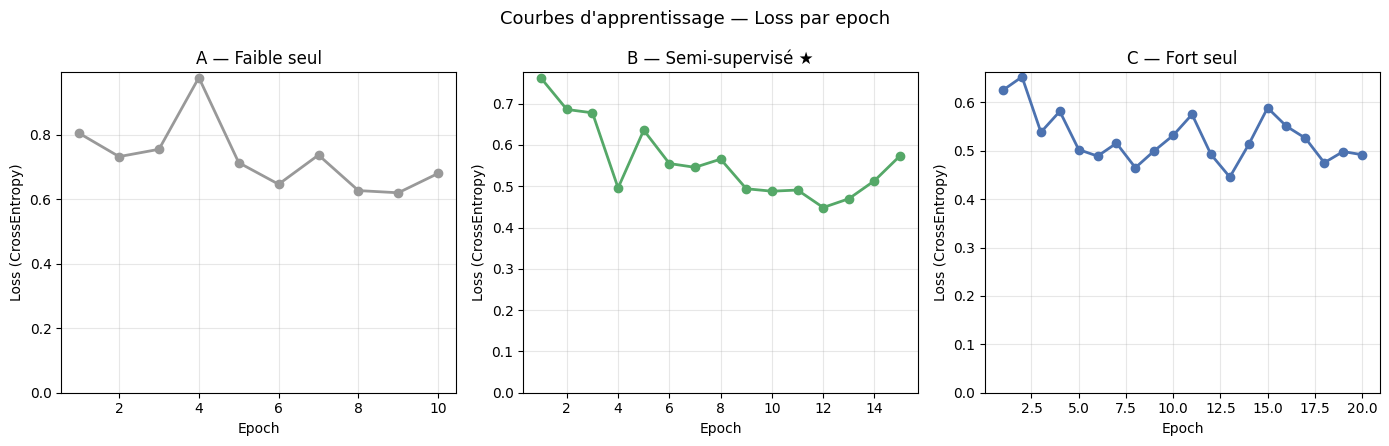

In [37]:
# Courbes d'apprentissage
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, (name, history, color) in zip(axes, [
    ("A — Faible seul",     history_A, "#999999"),
    ("B — Semi-supervisé ★", history_B, "#55A868"),
    ("C — Fort seul",        history_C, "#4C72B0"),
]):
    ax.plot(range(1, len(history)+1), history, marker="o", color=color, linewidth=2)
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (CrossEntropy)")
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
fig.suptitle("Courbes d'apprentissage — Loss par epoch", fontsize=13)
plt.tight_layout()
plt.savefig("courbes_apprentissage.png", dpi=130, bbox_inches="tight")
plt.show()


In [38]:
results_table = pd.DataFrame({
    "Modele"             : ["A faible seul", "B semi-supervise", "C fort seul (baseline)"],
    "Accuracy"           : [metrics_A["accuracy"],         metrics_B["accuracy"],         metrics_C["accuracy"]],
    "Precision cancer"   : [metrics_A["precision_cancer"], metrics_B["precision_cancer"], metrics_C["precision_cancer"]],
    "Rappel cancer etoile": [metrics_A["recall_cancer"],   metrics_B["recall_cancer"],    metrics_C["recall_cancer"]],
    "F1 cancer"          : [metrics_A["f1_cancer"],        metrics_B["f1_cancer"],        metrics_C["f1_cancer"]],
}).round(3)
print(results_table.to_string(index=False))

                Modele  Accuracy  Precision cancer  Rappel cancer etoile  F1 cancer
         A faible seul     0.433             0.444                 0.533      0.485
      B semi-supervise     0.767             0.722                 0.867      0.788
C fort seul (baseline)     0.667             0.600                 1.000      0.750


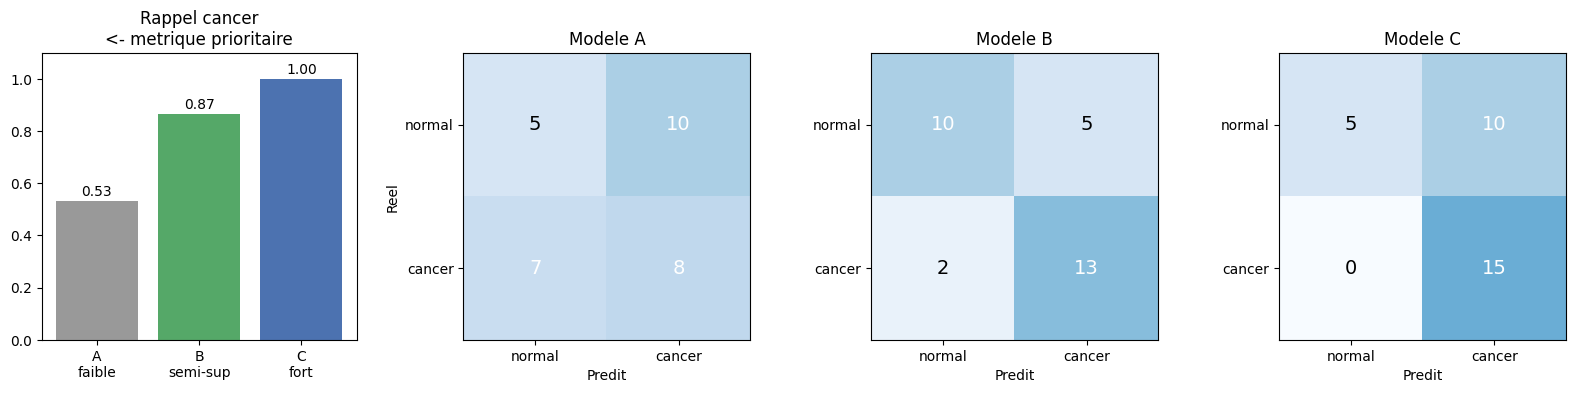

In [39]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
recalls = [metrics_A["recall_cancer"], metrics_B["recall_cancer"], metrics_C["recall_cancer"]]
bars = axes[0].bar(["A\nfaible","B\nsemi-sup","C\nfort"], recalls, color=["#999","#55A868","#4C72B0"])
axes[0].set_ylim(0,1.1); axes[0].set_title("Rappel cancer\n<- metrique prioritaire")
for b, v in zip(bars, recalls):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.2f}", ha="center")

for idx, (name, m) in enumerate([("A",metrics_A),("B",metrics_B),("C",metrics_C)]):
    ax = axes[idx+1]; cm = m["confusion"]
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=test_strong.shape[0])
    for i in range(2):
        for j in range(2):
            ax.text(j,i,str(cm[i,j]),ha="center",va="center",
                    color="white" if cm[i,j]>cm.max()/2 else "black", fontsize=14)
    ax.set_xticks([0,1]); ax.set_xticklabels(["normal","cancer"])
    ax.set_yticks([0,1]); ax.set_yticklabels(["normal","cancer"])
    ax.set_xlabel("Predit"); ax.set_ylabel("Reel" if idx==0 else ""); ax.set_title(f"Modele {name}")

plt.tight_layout(); plt.savefig("resultats_comparaison.png", dpi=130, bbox_inches="tight"); plt.show()

In [40]:
model_B.eval()
loader_u = DataLoader(ImgDatasetGray(df_weak["filepath"]), batch_size=32, shuffle=False)
preds_u, confs_u = [], []
with torch.no_grad():
    for xb in loader_u:
        out = model_B(xb.repeat(1,3,1,1).to(DEVICE))
        probs = torch.softmax(out, dim=1)
        preds_u.extend(out.argmax(1).cpu().numpy().tolist())
        confs_u.extend(probs.max(1).values.cpu().numpy().tolist())

df_weak["label_predit"] = [IDX2LABEL[p] for p in preds_u]
df_weak["confiance"]    = confs_u
print("Repartition predictions sur sans_label :")
print(df_weak["label_predit"].value_counts())
print(f"Confiance moyenne : {np.mean(confs_u):.3f}")
print(f"Images a faible confiance (<0.70) : {sum(c<0.70 for c in confs_u)}")
df_weak.to_csv("predictions_sans_label.csv", index=False)
print("Sauvegarde -> predictions_sans_label.csv")

Repartition predictions sur sans_label :
label_predit
cancer    1320
normal      54
Name: count, dtype: int64
Confiance moyenne : 0.896
Images a faible confiance (<0.70) : 31
Sauvegarde -> predictions_sans_label.csv


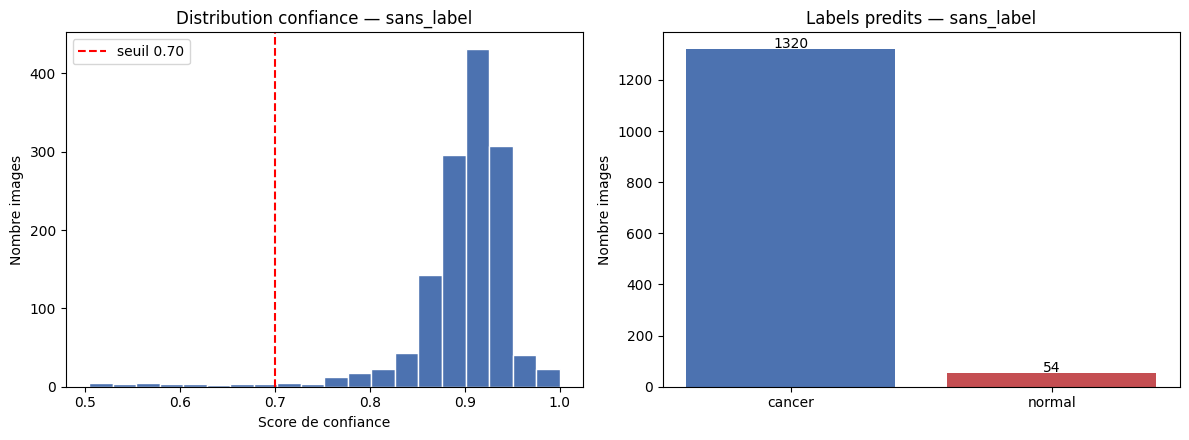

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(confs_u, bins=20, color="#4C72B0", edgecolor="white")
axes[0].axvline(0.70, color="red", linestyle="--", label="seuil 0.70")
axes[0].set_xlabel("Score de confiance"); axes[0].set_ylabel("Nombre images")
axes[0].set_title("Distribution confiance — sans_label"); axes[0].legend()

counts = df_weak["label_predit"].value_counts()
bars = axes[1].bar(counts.index, counts.values, color=["#4C72B0","#C44E52"])
for b, v in zip(bars, counts.values):
    axes[1].text(b.get_x()+b.get_width()/2, v+5, str(v), ha="center")
axes[1].set_ylabel("Nombre images"); axes[1].set_title("Labels predits — sans_label")
plt.tight_layout(); plt.savefig("predictions_distribution.png", dpi=130, bbox_inches="tight"); plt.show()

## Conclusion

| | Auto-encodeur | **RadImageNet** |
|--|--|--|
| Pré-entraînement | Nos données (1374 imgs) | **1.35M images médicales** |
| Dimension embeddings | 64 | **2048** |
| Pertinence médicale | Faible | **Élevée** |

RadImageNet est le choix le plus pertinent pour ce projet ses features ont été apprises sur des IRM, scanners et échographies, ce qui est directement adapté à notre tâche.

**Limite principale** : 30 images de test seulement — les métriques sont indicatives. Un jeu de test indépendant validé médicalement est nécessaire avant tout usage clinique.